# 01 · Remote-sensing data extraction (Google Earth Engine)

**Goal:** build a labelled point dataset for Tamil Nadu in which every point carries the physical,
spectral, climatic and infrastructure characteristics that decide whether land is suitable for a
utility-scale solar PV plant.

| Group | Predictor | Sensor / product | Native resolution | Why it matters |
|---|---|---|---|---|
| Climate | GHI, air temperature, cloud cover | NASA POWER (CERES / MERRA-2) | 1° / 0.5° | energy yield, panel efficiency loss with heat |
| Terrain | elevation, slope, aspect | SRTM GL1 v3 (C-band InSAR) | 30 m | construction cost, self-shading |
| Spectral | NDVI, NDBI | Sentinel-2 MSI L2A | 10–20 m | vegetation / built-up land to avoid |
| Thermal | land surface temperature | Landsat 8/9 TIRS C2 L2 | 100 m (resampled 30 m) | surface heat regime |
| Land cover | 11-class map | ESA WorldCover v200 (2021) | 10 m | legal / practical exclusions |
| Infrastructure | distance to road, power line, substation | OpenStreetMap | vector | access & grid connection |

**Labels:** positives = points inside OSM-mapped solar plants (`power=plant` + `plant:source=solar`
and ground-mounted `generator:source=solar` arrays); negatives = random points across the state,
≥ 1 km from any plant.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from model import config
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})


## 1. Earth Engine & study region

In [2]:
from model import gee, osm
gee.init_ee()
gj = gee.save_region_geojson()
region = osm.region_polygon_from_geojson(gj)
region_gdf = gpd.GeoDataFrame(geometry=[region], crs=4326)
area_km2 = region_gdf.to_crs(config.METRIC_EPSG).area.iloc[0] / 1e6
print(f"{config.REGION_NAME}: {area_km2:,.0f} km²  |  bounds {tuple(round(b, 2) for b in region.bounds)}")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Tamil Nadu: 130,199 km²  |  bounds (76.23, 8.08, 80.35, 13.56)


## 2. Earth Engine feature stack

All raster predictors are combined into **one multi-band `ee.Image`**, so a single `reduceRegions`
call returns every band for hundreds of points at once.

* **Sentinel-2** — `COPERNICUS/S2_SR_HARMONIZED`, Sep 2025 → Sep 2026, scenes with < 60 % cloud,
  per-pixel mask from **Cloud Score+** (`cs_cdf ≥ 0.60`), reflectance = DN / 10 000, median composite.
  NDVI = (B8 − B4)/(B8 + B4); NDBI = (B11 − B8)/(B11 + B8). B11 (20 m) is resampled to 10 m.
* **Landsat 8/9** — Collection-2 Level-2; clouds, cirrus, shadows and fill removed with `QA_PIXEL`
  bits 0–4; LST (°C) = `ST_B10` × 0.00341802 + 149.0 − 273.15; 12-month median.
* **SRTM** — slope and aspect from `ee.Terrain` (3 × 3 finite-difference kernel).
* **WorldCover** — `ESA/WorldCover/v200`, band `Map`.
* **Baseline (ablation)** — Landsat 8 2013-04 → 2015-03 NDVI, NDBI, LST from *before* most plants
  were built, to test whether the model is learning "suitability" or just "looks like panels".

In [3]:
stack = gee.feature_image()
print('bands:', stack.bandNames().getInfo())
s2_count = (gee.ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(gee.region_geometry())
            .filterDate(config.COMPOSITE_START, config.COMPOSITE_END)
            .filter(gee.ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 60)).size().getInfo())
ls_count = (gee.ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').merge(gee.ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
            .filterBounds(gee.region_geometry())
            .filterDate(config.COMPOSITE_START, config.COMPOSITE_END)
            .filter(gee.ee.Filter.lt('CLOUD_COVER', 70)).size().getInfo())
print(f'Sentinel-2 scenes in composite: {s2_count}  |  Landsat 8/9 scenes: {ls_count}')

bands: ['elevation', 'slope', 'aspect', 'ndvi', 'ndbi', 'lst', 'landcover', 'ndvi_pre', 'ndbi_pre', 'lst_pre']


Sentinel-2 scenes in composite: 2086  |  Landsat 8/9 scenes: 468


### Layer previews (rendered by Earth Engine, stitched from Mercator tiles)

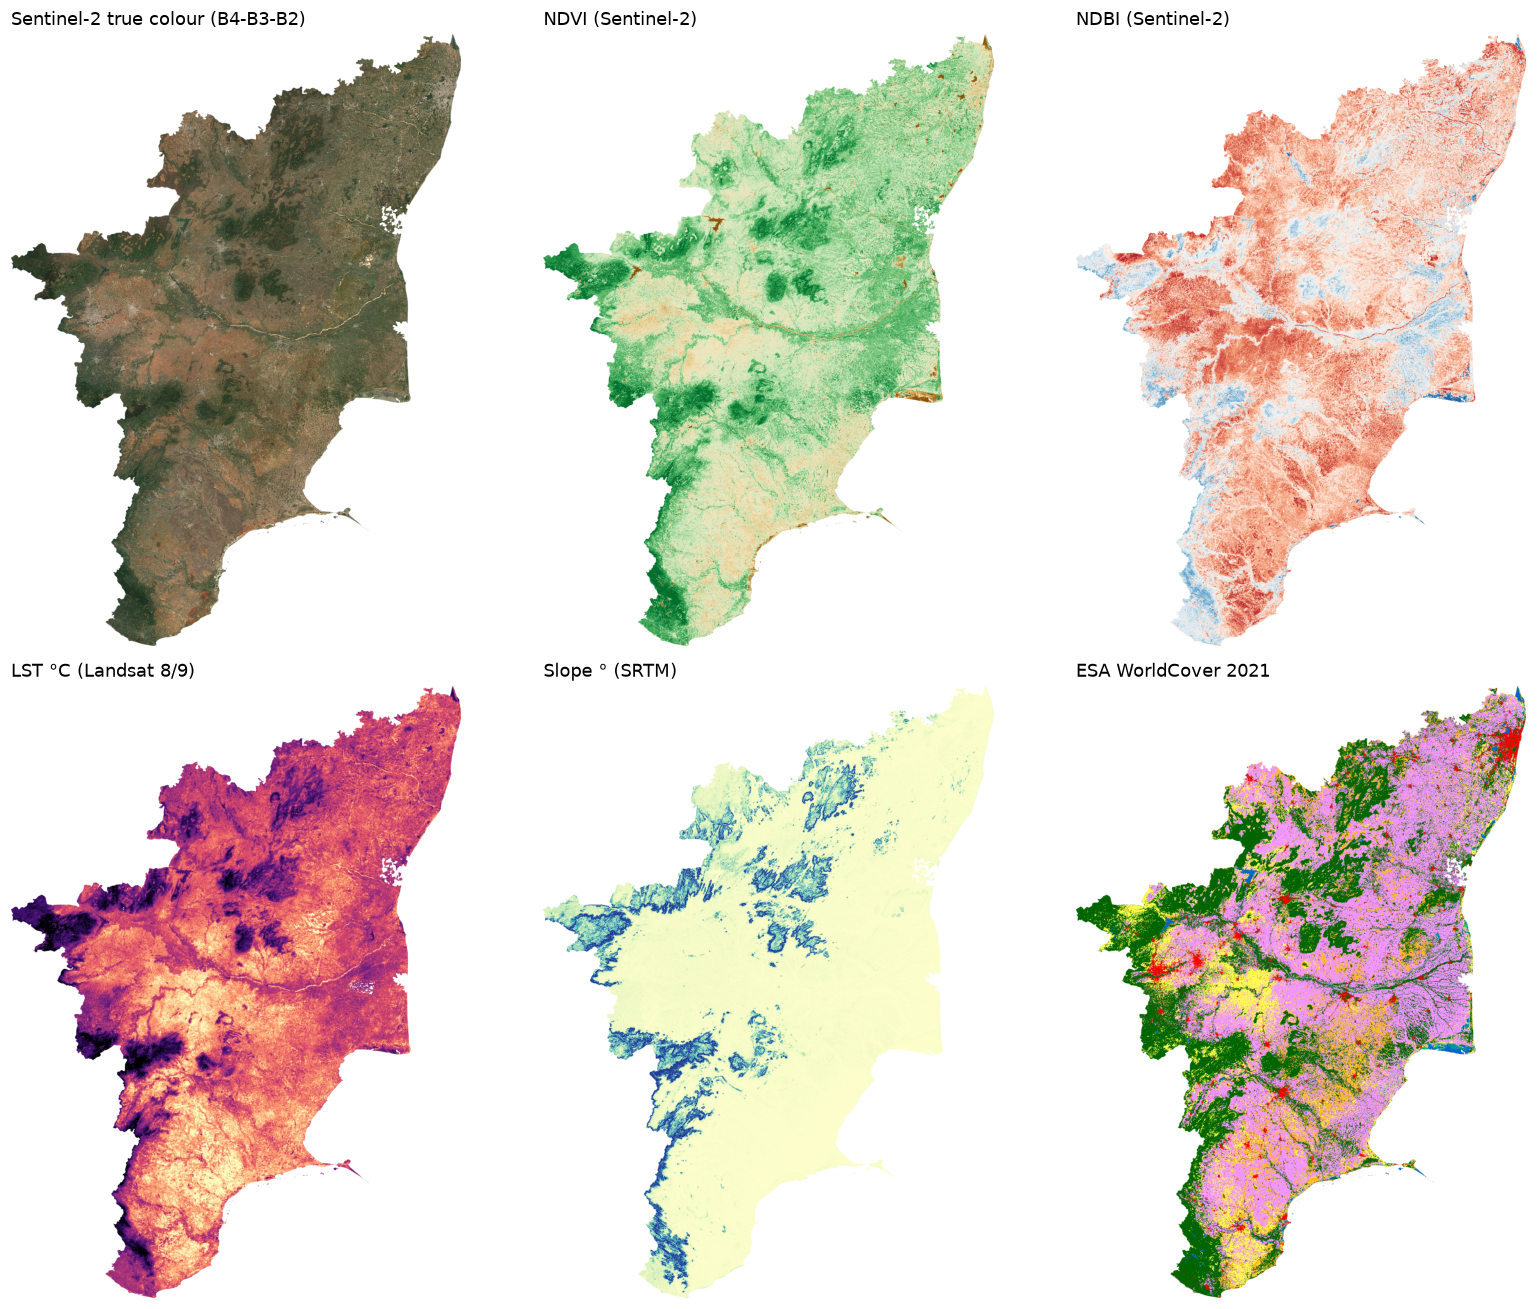

In [4]:
from PIL import Image
layers = json.loads((config.PROCESSED_DIR / 'layers' / 'layers.json').read_text())
titles = {'truecolor': 'Sentinel-2 true colour (B4-B3-B2)', 'ndvi': 'NDVI (Sentinel-2)',
          'ndbi': 'NDBI (Sentinel-2)', 'lst': 'LST °C (Landsat 8/9)', 'slope': 'Slope ° (SRTM)',
          'elevation': 'Elevation m (SRTM)', 'landcover': 'ESA WorldCover 2021'}
order = ['truecolor', 'ndvi', 'ndbi', 'lst', 'slope', 'landcover']
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
for ax, name in zip(axes.ravel(), order):
    ax.imshow(Image.open(config.PROCESSED_DIR / 'layers' / layers[name]['file']))
    ax.set_title(titles[name], fontsize=12, loc='left'); ax.axis('off')
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'rs_layers_overview.png', bbox_inches='tight')
plt.show()

## 3. Training labels from OpenStreetMap

In [5]:
sites = gpd.read_file(config.SOLAR_POLYGONS_GEOJSON)
df = pd.read_csv(config.DATASET_CSV)
print(f"solar sites: {len(sites)}   total footprint: {sites['area_m2'].sum()/1e6:.1f} km²")
print(f"largest sites:")
display(sites.sort_values('area_m2', ascending=False)[['site_id', 'name', 'area_m2', 'start_date']]
        .head(8).assign(area_km2=lambda d: (d.area_m2 / 1e6).round(2)).drop(columns='area_m2'))
print(df['label'].value_counts().rename({1: 'solar (positive)', 0: 'non-solar (negative)'}))

solar sites: 344   total footprint: 87.7 km²
largest sites:


,site_id,name,start_date,area_km2
149,S0149,,,3.39
284,S0284,,,3.07
184,S0184,,,2.92
85,S0085,Narikudi,,2.69
103,S0103,,,2.31
154,S0154,,,2.13
249,S0249,,,1.70
77,S0077,,,1.51


label
non-solar (negative)    2652
solar (positive)        1768
Name: count, dtype: int64


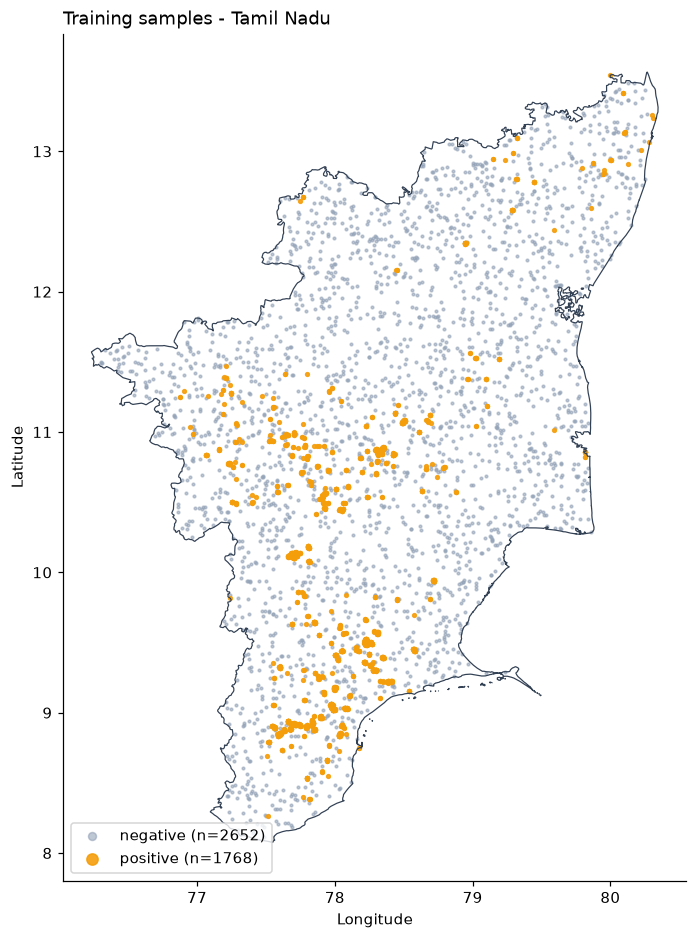

In [6]:
fig, ax = plt.subplots(figsize=(8, 10))
region_gdf.boundary.plot(ax=ax, color='#334155', lw=0.8)
neg, pos = df[df.label == 0], df[df.label == 1]
ax.scatter(neg.lon, neg.lat, s=3, c='#94a3b8', alpha=0.6, label=f'negative (n={len(neg)})')
ax.scatter(pos.lon, pos.lat, s=6, c='#f59e0b', alpha=0.9, label=f'positive (n={len(pos)})')
ax.set_title(f'Training samples - {config.REGION_NAME}', loc='left')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.legend(loc='lower left', markerscale=3)
ax.set_aspect(1 / np.cos(np.deg2rad(11)))
plt.savefig(config.FIGURES_DIR / 'training_samples_map.png', bbox_inches='tight'); plt.show()

## 4. Final dataset

In [7]:
from model.features import RAW_FEATURE_COLS
print(df.shape)
display(df.head())
display(df[RAW_FEATURE_COLS].describe().T.round(3))
print('missing values per column:')
print(df[RAW_FEATURE_COLS].isna().sum()[lambda s: s > 0])

(4420, 23)


,pid,lat,lon,label,group_id,site_id,site_area_ha,ghi,temperature,cloud_cover,...,ndvi,ndbi,lst,landcover,dist_road_km,dist_powerline_km,dist_substation_km,ndvi_pre,ndbi_pre,lst_pre
0,P00000,13.239601,80.307906,1,S0000,S0000,0.697602,5.175400,28.129718,55.390000,...,0.302034,0.105184,40.936947,30,0.392825,0.486185,0.613809,0.250510,0.077572,40.921566
1,P00001,13.258438,80.305222,1,S0001,S0001,4.118912,5.175400,28.130193,55.390000,...,0.196172,0.189627,39.641518,30,0.190753,0.382814,1.252048,0.552519,-0.076281,37.430061
2,P00002,13.069836,80.279403,1,S0002,S0002,0.964127,5.175400,28.093942,55.390000,...,0.606135,-0.018255,36.599480,30,0.117650,2.892906,0.886880,0.296637,0.064484,38.720364
3,P00003,13.008804,80.223815,1,S0003,S0003,0.976848,5.175400,28.056161,55.390000,...,0.593758,-0.097112,36.132919,10,0.185999,2.849571,1.333569,0.598004,-0.162028,38.004288
4,P00004,12.913281,80.125381,1,S0004,S0004,0.902065,5.200479,28.004546,55.912047,...,0.328113,0.135725,40.014084,30,0.095031,2.802123,2.767783,0.624573,-0.170682,37.088257


,count,mean,std,min,25%,50%,75%,max
ghi,4420.0,5.391,0.086,5.093,5.354,5.385,5.453,5.563
temperature,4420.0,26.903,1.198,23.508,26.101,27.198,27.975,28.373
cloud_cover,4420.0,62.159,2.661,55.390,60.729,61.909,63.512,69.260
elevation,4420.0,223.994,293.021,-4.000,59.000,122.000,271.000,2446.000
slope,4420.0,3.983,5.960,0.000,1.321,2.096,3.705,60.182
aspect,4420.0,155.928,105.233,0.000,71.772,152.934,244.668,357.993
ndvi,4420.0,0.355,0.199,-0.560,0.200,0.307,0.500,0.889
ndbi,4420.0,0.081,0.195,-0.693,-0.046,0.091,0.226,0.554
lst,4411.0,40.623,5.293,19.287,37.489,41.614,44.654,53.567
landcover,4420.0,32.316,14.851,10.000,20.000,30.000,40.000,95.000


missing values per column:
lst        9
lst_pre    9
dtype: int64


In [8]:
summary = df.groupby('label')[RAW_FEATURE_COLS].median().T
summary.columns = ['non-solar median', 'solar median']
summary.round(3)

,non-solar median,solar median
ghi,5.369,5.421
temperature,26.973,27.414
cloud_cover,61.229,63.360
elevation,158.000,100.000
slope,2.640,2.079
aspect,152.926,152.987
ndvi,0.450,0.199
ndbi,-0.008,0.251
lst,38.418,44.545
landcover,30.000,40.000


---
# Part B · Global dataset

To make the model work **anywhere on Earth**, every predictor is swapped for a dataset with global
coverage inside the Earth Engine catalog, so a single `reduceRegions` request returns all features for
any coordinate — no per-point calls to external APIs.

| Group | Predictor | Global dataset | Resolution |
|---|---|---|---|
| Climate | GHI, 2 m air temperature | ERA5-Land monthly (2005-2024 mean) | ~9 km |
| Climate | cloud fraction | MODIS Terra MOD08_M3 | 1° |
| Terrain | elevation, slope, aspect | Copernicus DEM GLO-30 (X-band TanDEM-X) | 30 m, pole-to-pole |
| Spectral | NDVI | MODIS MOD13A1 | 500 m |
| Spectral | NDBI (b6 SWIR-1, b2 NIR) | MODIS MOD09A1 | 500 m |
| Thermal | daytime LST | MODIS MOD11A2 | 1 km |
| Land cover | IGBP class | MODIS MCD12Q1 (annual) | 500 m |
| Human | travel time to city | Malaria Atlas Project accessibility 2015 | 1 km |
| Human | night-time lights | VIIRS DNB monthly (stray-light corrected) | ~460 m |
| Human | population density | GHSL P2023A | 100 m |

**Labels:** Kruitwagen *et al.* (2021, *Nature*) global PV inventory — 68 661 plant polygons detected
with ML on Sentinel-2 and SPOT imagery. One interior point per plant ≥ 1 ha, stratified by world region.
Negatives: 50 % area-uniform background on land, 50 % *hard* negatives 5–100 km from a plant.

### Label leakage and the pre-construction epoch
Satellites observing an existing plant see **the panels**, not the land that was chosen. If NDVI,
land cover, etc. are measured *now*, a model learns "what a solar farm looks like". Time-varying
predictors are therefore sampled from a **2008–2010 baseline** (before almost all inventory plants were
built); at prediction time the same variables are measured *now* — the land a new plant would replace.

In [9]:
from model.features import IGBP_NAMES
g = pd.read_csv(config.GLOBAL_DATASET_CSV)
print(g.shape)
display(pd.crosstab(g['region'], g['label'].map({1: 'solar', 0: 'non-solar'}), margins=True))
display(g.groupby(['label', 'neg_type'], dropna=False).size().rename('n'))

(17213, 34)


label,non-solar,solar,All
region,,,
Africa,1220,225,1445
Central & North Asia,517,16,533
East Asia,1122,1400,2522
Europe,1053,1400,2453
Latin America,781,398,1179
Middle East,1051,1400,2451
North America,1530,1400,2930
Oceania,335,104,439
South Asia,983,1400,2383


label  neg_type  
0      background    4500
       hard          4500
1      NaN           8213
Name: n, dtype: int64

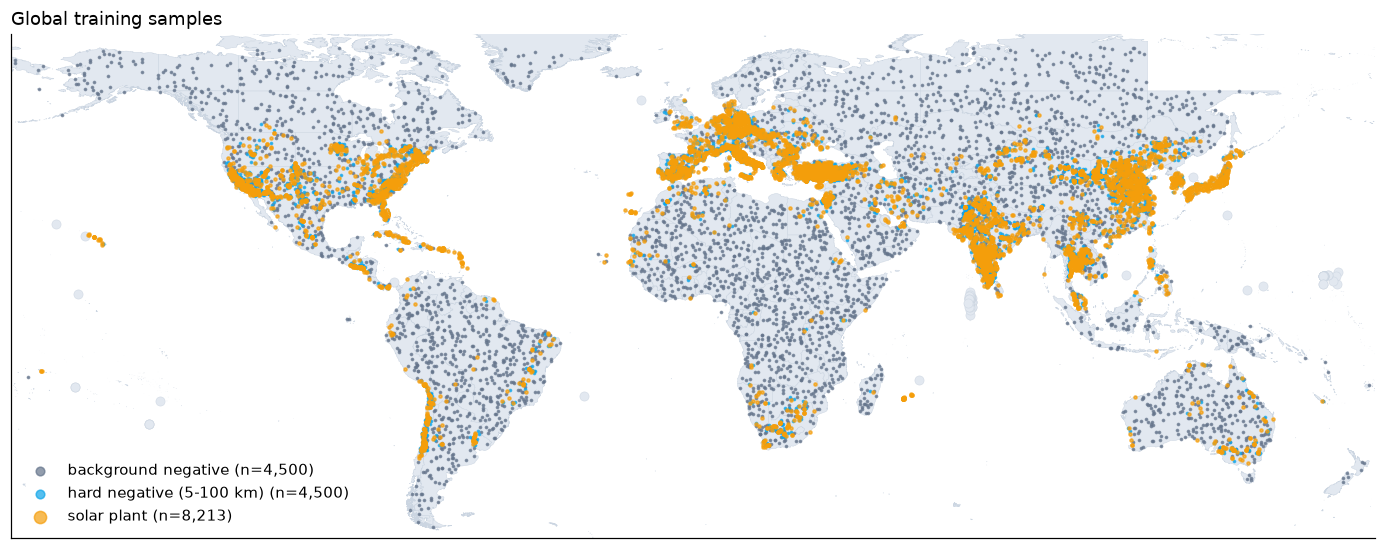

In [10]:
regions = gpd.read_file(config.WORLD_REGIONS_GEOJSON)
fig, ax = plt.subplots(figsize=(16, 8))
regions.plot(ax=ax, color='#e2e8f0', edgecolor='#cbd5e1', lw=0.3)
for (lab, nt), c, s, name in [((0, 'background'), '#64748b', 2, 'background negative'),
                              ((0, 'hard'), '#0ea5e9', 2, 'hard negative (5-100 km)'),
                              ((1, None), '#f59e0b', 4, 'solar plant')]:
    sub = g[(g.label == lab) & ((g.neg_type == nt) if nt else True)]
    ax.scatter(sub.lon, sub.lat, s=s, c=c, alpha=0.7, label=f'{name} (n={len(sub):,})')
ax.set_xlim(-180, 180); ax.set_ylim(-58, 75); ax.set_aspect('equal')
ax.legend(loc='lower left', markerscale=4, frameon=False)
ax.set_title('Global training samples', loc='left'); ax.set_xticks([]); ax.set_yticks([])
plt.savefig(config.FIGURES_DIR / 'global_training_samples.png', bbox_inches='tight'); plt.show()

### Evidence of leakage: land cover at plant locations, then vs now

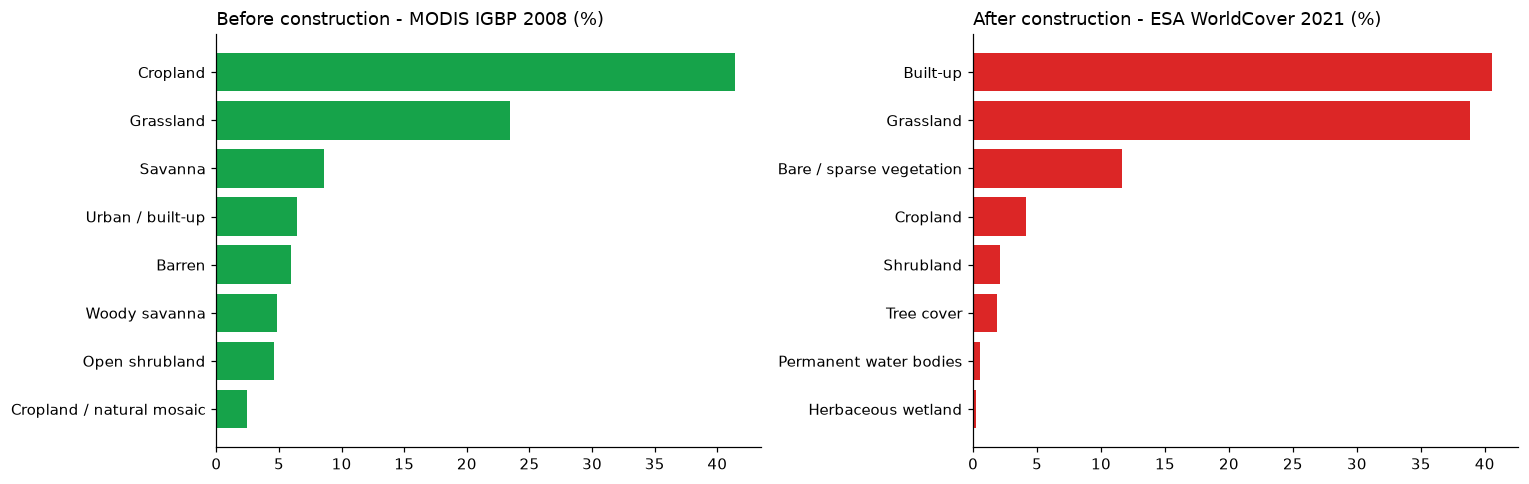

Median at plant locations:


,2008-10 (pre),now
ndvi,0.377,0.433
ndbi,-0.004,-0.033
lst,26.570,22.290
nightlights,0.522,1.365
population,0.000,0.000


In [11]:
from model.config import WORLDCOVER_CLASSES
pos = g[g.label == 1]
pre = pos['landcover_pre'].round().map(IGBP_NAMES).value_counts(normalize=True).head(8) * 100
now = pos['worldcover'].round().map(WORLDCOVER_CLASSES).value_counts(normalize=True).head(8) * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(pre.index[::-1], pre.values[::-1], color='#16a34a')
axes[0].set_title('Before construction - MODIS IGBP 2008 (%)', loc='left')
axes[1].barh(now.index[::-1], now.values[::-1], color='#dc2626')
axes[1].set_title('After construction - ESA WorldCover 2021 (%)', loc='left')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / 'leakage_landcover_then_vs_now.png', bbox_inches='tight'); plt.show()
cols = ['ndvi', 'ndbi', 'lst', 'nightlights', 'population']
d = pd.DataFrame({'2008-10 (pre)': [pos[f'{c}_pre'].median() for c in cols],
                  'now': [pos[c].median() for c in cols]}, index=cols)
print('Median at plant locations:'); display(d.round(3))

In [12]:
print('missing values (%):')
print((g.drop(columns=['install_date', 'lc_before', 'neg_type', 'unique_id', 'area_m2', 'capacity_mw'])
       .isna().mean() * 100).round(2)[lambda s: s > 0])

missing values (%):
ghi              0.02
temperature      0.02
accessibility    0.27
ndvi_pre         0.30
ndbi_pre         0.04
lst_pre          0.30
ndvi             0.34
ndbi             0.05
lst              0.30
biome            0.40
dtype: float64
